# Decision Tree Worksheet

In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import graphviz
import matplotlib.pyplot as plt

## Loading data

Load Pima diabetes dataset and split data, with test size 20% and validaton 20%.

In [3]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

data = pd.read_csv(url,names = names)
## YOUR CODE HERE

X = data[['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']]
y = data['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2)



## Creating Model

Make a model using sklearn's DecisionTreeClassifier, with a high max-depth and low minimum sample leafs.

In [4]:
## YOUR CODE HERE
model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=2)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=2)

Print accuracy of training and validation data.

In [5]:
## YOUR CODE HERE
y_train_pred_overfit = model.predict(X_train)
print(f"Training accuracy: {metrics.accuracy_score(y_train, y_train_pred_overfit)}")

y_val_pred_overfit = model.predict(X_val)
print(f"Validation accuracy: {metrics.accuracy_score(y_val, y_val_pred_overfit)}")

Training accuracy: 0.9653767820773931
Validation accuracy: 0.6504065040650406


Make a model with a low max-depth and higher minimum sample leafs.

In [ ]:
## YOUR CODE HERE
model = DecisionTreeClassifier(max_depth=2, min_samples_leaf=20)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=20)

Print accuracy of training and validation data.

In [7]:
## YOUR CODE HERE
y_train_pred = model.predict(X_train)
print(f"Training accuracy: {metrics.accuracy_score(y_train, y_train_pred)}")

y_val_pred = model.predict(X_val)
print(f"Validation accuracy: {metrics.accuracy_score(y_val, y_val_pred)}")

Training accuracy: 0.780040733197556
Validation accuracy: 0.7642276422764228


Explain the accuracy results below. 

Allowing a decision tree too much depth will cause it to remember the data rather than make good predictions so training accuracy will be much higher than the validation accuracy. By constraining the depth before it creates a leaf, we are able to cap this and manage this better allowing the training and validation data to be closer to eachother. 

## Metrics

Plot the ROC curve and print the AUC of the second model.

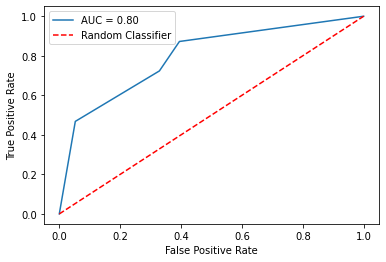

ROC-AUC: 0.7960526315789473


In [11]:
## YOUR CODE HERE
y_val_prob = model.predict_proba(X_val)[:,1]

fpr, tpr, thresholds = metrics.roc_curve(y_val, y_val_prob)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
display.plot()
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Classifier")
plt.legend()
plt.show()

print(f"ROC-AUC: {roc_auc}")

Use graphviz to visualize your 2nd tree.

In [ ]:
## YOUR CODE HERE
dot_data = tree.export_graphviz(model, out_file=None, filled=True)

graph = graphviz.Source(dot_data)
graph

ExecutableNotFound: failed to execute 'dot', make sure the Graphviz executables are on your systems' PATH

#### Use the graph above to answer the questions below

Question 1: What do you think X[n] represents in the nodes from the graph?

The feature of the node

Question 2: What is the root feature? Does it make sense as the root feature?

The root feature is plas x[1] and it makes sense because it's usually linked back to diabetes. 

Question 3: If you were to change the parameters to have a max_depth of 500 and min_samples_leaf of 1, what do you think the effect would be on the test accuracy? Training accuracy?

Such a high max_depth would cause the training_accuracy to go up while test_accuracy would start to dip. 

**Test your guesses, create a model with max_depth=500 and min_samples_leaf=1, and predict values for the training and validation data**

In [18]:
## YOUR CODE HERE

model_extreme = DecisionTreeClassifier(max_depth=500, min_samples_leaf=1)
model_extreme.fit(X_train, y_train)

y_train_pred = model_extreme.predict(X_train)
y_val_pred = model_extreme.predict(X_val)

train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

print('Training Accuracy: {:.3f}'.format(train_accuracy))
print('Validation Accuracy: {:.3f}'.format(val_accuracy))

Training Accuracy: 1.000
Validation Accuracy: 0.659


# Random Forest

## Creating Model

Create a model with sklearn's RandomForestClassifier and predict values on your validation set.

In [21]:
## YOUR CODE HERE
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=0)
rf_model.fit(X_train, y_train)

y_val_pred_rf = rf_model.predict(X_val)

Print accuracy of training and validation data.

In [22]:
## YOUR CODE HERE
y_train_pred_rf = rf_model.predict(X_train)
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
val_accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
print('Training Accuracy: {:.3f}'.format(train_accuracy_rf))
print('Validation Accuracy: {:.3f}'.format(val_accuracy_rf))

Training Accuracy: 1.000
Validation Accuracy: 0.789


How did the accuracy compare to the decision tree's accuracy?

(YOUR ANSWER HERE)

It achieved a 1.000 training accuracy similar to the uncontrolled decision tree, however it achieved a greater Validation accuracy, showing that multiple trees gives a better generalization of the data. 

Print the 3 most important features (hint: sklearn has an attribute to help you find these)

In [25]:
## YOUR CODE HERE
importances = rf_model.feature_importances_
feature_names = X_train.columns

importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(importance_series.head(3))

plas    0.258872
mass    0.167628
pedi    0.135630
dtype: float64


Find the accuracy for random forests with 1 to 100 trees, counting by 5. Print and then plot these accuracies.


n_estimators=1: Validation Accuracy=0.683
n_estimators=6: Validation Accuracy=0.740
n_estimators=11: Validation Accuracy=0.732
n_estimators=16: Validation Accuracy=0.756
n_estimators=21: Validation Accuracy=0.789
n_estimators=26: Validation Accuracy=0.780
n_estimators=31: Validation Accuracy=0.780
n_estimators=36: Validation Accuracy=0.764
n_estimators=41: Validation Accuracy=0.772
n_estimators=46: Validation Accuracy=0.780
n_estimators=51: Validation Accuracy=0.789
n_estimators=56: Validation Accuracy=0.797
n_estimators=61: Validation Accuracy=0.789
n_estimators=66: Validation Accuracy=0.789
n_estimators=71: Validation Accuracy=0.805
n_estimators=76: Validation Accuracy=0.789
n_estimators=81: Validation Accuracy=0.789
n_estimators=86: Validation Accuracy=0.797
n_estimators=91: Validation Accuracy=0.797
n_estimators=96: Validation Accuracy=0.789


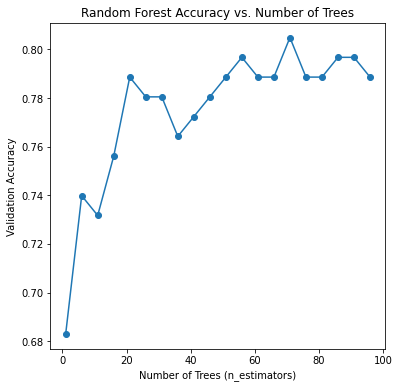

In [27]:
## YOUR CODE HERE
n_estimators_range = range(1, 101, 5)
rf_accuracies = []

for n in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=0)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_val, rf.predict(X_val))
    rf_accuracies.append(acc)
    print('n_estimators={}: Validation Accuracy={:.3f}'.format(n, acc))

plt.figure(figsize=(6,6))
plt.plot(list(n_estimators_range), rf_accuracies, marker = 'o')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Validation Accuracy')
plt.title('Random Forest Accuracy vs. Number of Trees')
plt.show()


Plot the roc_curve using predict_proba a function for our random forest model, and metrics.roc_curve

It might help to google these functions and look at sklearn's documentation.

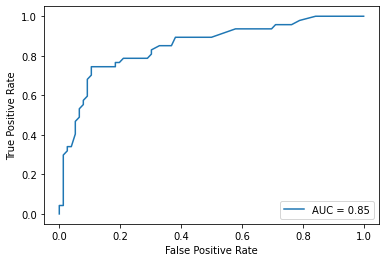

In [31]:
## YOUR CODE HERE
y_val_prob = rf_model.predict_proba(X_val)[:,1] 
fpr, tpr, thresholds = metrics.roc_curve(y_val, y_val_prob)
curve = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=metrics.auc(fpr, tpr))
curve.plot()